# Session 11 - Central Limit Theorem (CLT)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, norm

np.random.seed(42)

## Task 1 — CLT Simulation: 1000 Samples of Size 30 (Skewed Instagram Likes)

The 'population' below is a right-skewed lognormal distribution standing in for Instagram post like counts (most posts get modest likes, a few go viral).

Population mean: 204.59 | std: 192.94
Population skewness: 3.538
Sample means (n=30) -> mean: 202.69 | std: 34.73
Sample means (n=30) skewness: 0.457


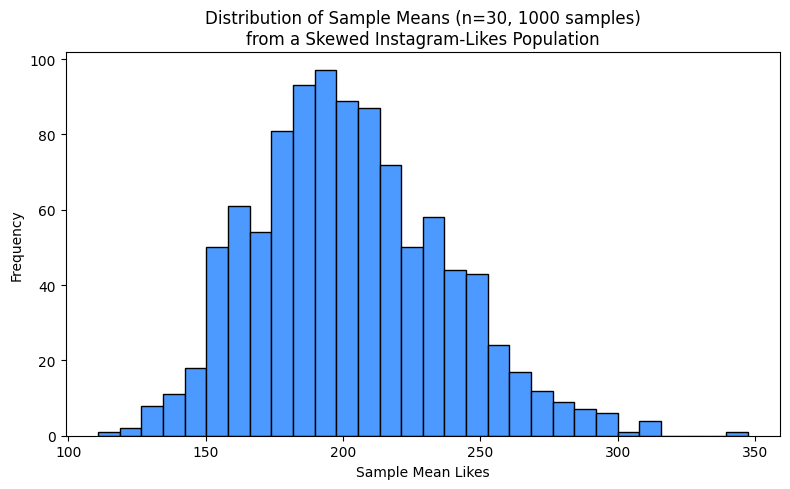

In [2]:
population = np.random.lognormal(mean=5, sigma=0.8, size=100000)
print('Population mean:', round(population.mean(), 2), '| std:', round(population.std(), 2))
print('Population skewness:', round(skew(population), 3))

n30_means = np.array([np.random.choice(population, size=30, replace=False).mean() for _ in range(1000)])
print('Sample means (n=30) -> mean:', round(n30_means.mean(), 2), '| std:', round(n30_means.std(), 2))
print('Sample means (n=30) skewness:', round(skew(n30_means), 3))

plt.figure(figsize=(8, 5))
plt.hist(n30_means, bins=30, color='#4c9aff', edgecolor='black')
plt.title('Distribution of Sample Means (n=30, 1000 samples)\nfrom a Skewed Instagram-Likes Population')
plt.xlabel('Sample Mean Likes')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Task 2 — Why the Sampling Distribution of the Mean Becomes Normal

Individual Zomato order amounts are skewed — most orders cluster around a modest value, but a handful of large family-size or bulk orders stretch the distribution's right tail. If you looked at a histogram of single order amounts, it clearly wouldn't be a bell curve. But if you instead took, say, 30 random orders at a time, averaged them, and repeated that many times, the histogram of *those averages* would start looking roughly normal — bell-shaped and symmetric around the true average order value.

That happens because averaging cancels out randomness in both directions: a sample that happens to grab a few unusually large orders tends to be balanced out, over many repeated samples, by other samples that grab smaller ones. The extreme highs and lows wash out on average, while the results cluster more tightly around the true mean the larger the sample size gets — that clustering-around-the-center effect is exactly what produces a normal shape, regardless of how skewed the original order-amount data was.

## Task 3 — Real-World Use Case: CLT for Swiggy Delivery Time Analytics

Swiggy's individual delivery times are almost certainly not normally distributed — most fall in a typical window, but traffic, weather, or a busy restaurant can create a long tail of slow deliveries. If an analyst wants to estimate the *average* delivery time for a city and put a confidence interval around it, the CLT is what makes that possible: by repeatedly sampling batches of deliveries (say, 50 orders at a time) and looking at the distribution of those batch averages, the analyst can treat that distribution as approximately normal even though single delivery times are skewed. That, in turn, lets Swiggy use standard normal-based formulas to build confidence intervals, run A/B tests comparing delivery-time changes across regions, and set realistic SLAs — all without needing the underlying delivery-time data itself to be normal.

## Task 4 — Comparing Sample Sizes: n=5 vs n=30

Sample means (n=5) -> mean: 206.4 | std: 88.43
Sample means (n=5) skewness: 1.709
Sample means (n=30) std for comparison: 34.73 | skewness: 0.457


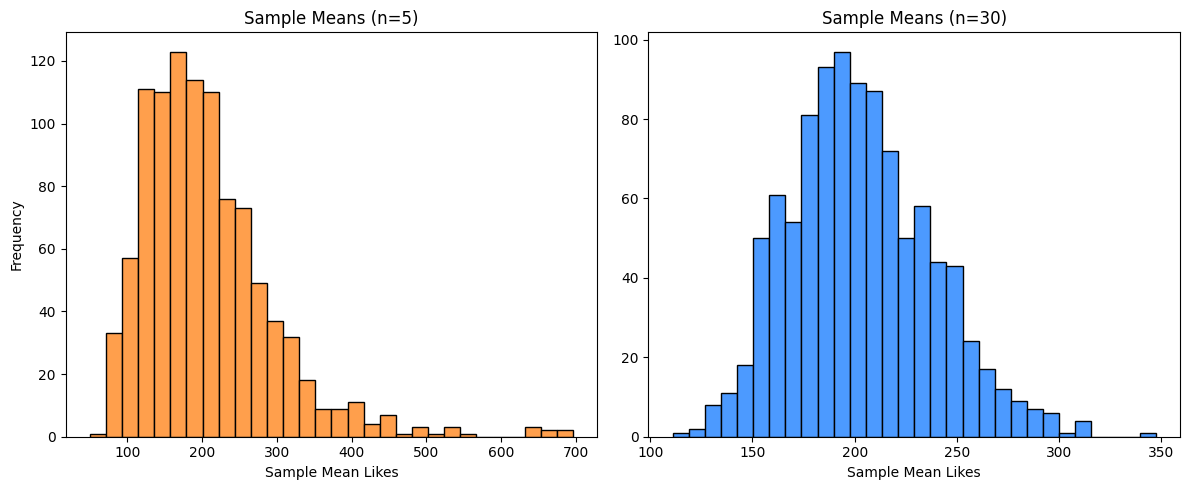

In [3]:
n5_means = np.array([np.random.choice(population, size=5, replace=False).mean() for _ in range(1000)])

print('Sample means (n=5) -> mean:', round(n5_means.mean(), 2), '| std:', round(n5_means.std(), 2))
print('Sample means (n=5) skewness:', round(skew(n5_means), 3))
print('Sample means (n=30) std for comparison:', round(n30_means.std(), 2), '| skewness:', round(skew(n30_means), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
axes[0].hist(n5_means, bins=30, color='#ff9f4c', edgecolor='black')
axes[0].set_title('Sample Means (n=5)')
axes[0].set_xlabel('Sample Mean Likes')
axes[0].set_ylabel('Frequency')

axes[1].hist(n30_means, bins=30, color='#4c9aff', edgecolor='black')
axes[1].set_title('Sample Means (n=30)')
axes[1].set_xlabel('Sample Mean Likes')

plt.tight_layout()
plt.show()

**What changes:** with n=5, the histogram is visibly wider and still noticeably right-skewed (skewness ≈ 1.7) — it hasn't fully shaken off the shape of the original skewed population yet. With n=30, the histogram is narrower (about 2.5x tighter spread, matching the √(30/5) ≈ 2.45 factor predicted by theory) and much closer to symmetric (skewness ≈ 0.46). Larger samples both average out the skew faster *and* shrink the spread of the sample means — both effects come from the same $\sigma/\sqrt{n}$ relationship.

## Task 5 — CLT with a Non-Normal (Exponential) Distribution

**AI-generated code** (via ChatGPT-style prompt: *'write Python code demonstrating the Central Limit Theorem using random samples from an exponential distribution'*), run below:

Exponential population -> mean: 49.89 | skewness: 2.009
Sample means (n=30) -> mean: 49.76 | skewness: 0.356


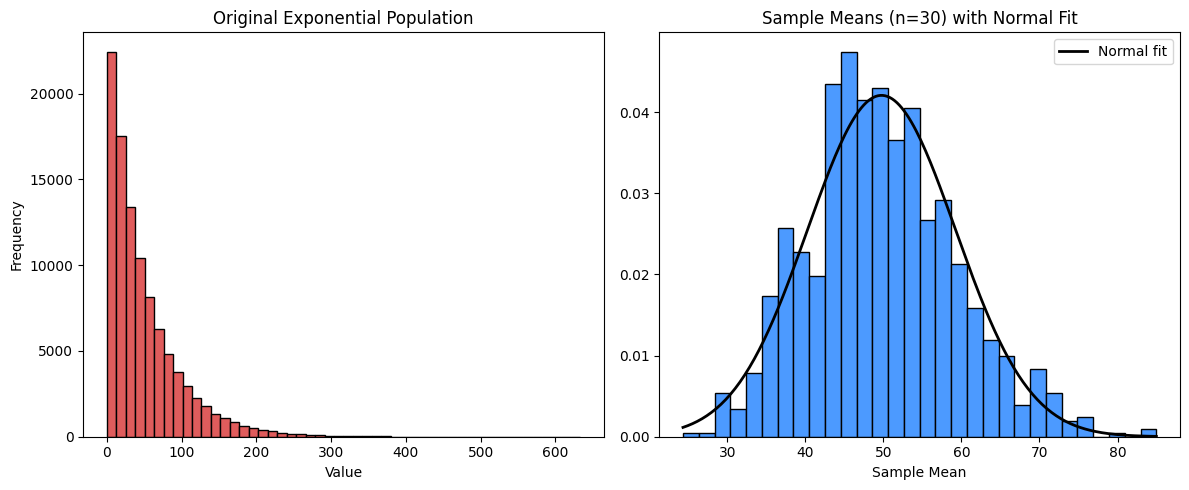

In [4]:
exp_population = np.random.exponential(scale=50, size=100000)
exp_sample_means = np.array([np.random.choice(exp_population, size=30, replace=False).mean() for _ in range(1000)])

print('Exponential population -> mean:', round(exp_population.mean(), 2), '| skewness:', round(skew(exp_population), 3))
print('Sample means (n=30) -> mean:', round(exp_sample_means.mean(), 2), '| skewness:', round(skew(exp_sample_means), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(exp_population, bins=50, color='#e05c5c', edgecolor='black')
axes[0].set_title('Original Exponential Population')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(exp_sample_means, bins=30, color='#4c9aff', edgecolor='black', density=True)
x = np.linspace(exp_sample_means.min(), exp_sample_means.max(), 200)
axes[1].plot(x, norm.pdf(x, exp_sample_means.mean(), exp_sample_means.std()), color='black', linewidth=2, label='Normal fit')
axes[1].set_title('Sample Means (n=30) with Normal Fit')
axes[1].set_xlabel('Sample Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observation:** the original exponential population (left) is heavily right-skewed with a sharp peak near zero and a long tail — nothing like a bell curve. The distribution of sample means (right), even though it comes from that same skewed source, closely tracks the overlaid normal curve. This is the CLT in its clearest form: no matter how oddly shaped the original distribution is, averaging repeated samples of a reasonable size (here, n=30) produces something close to normal.